In [32]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [33]:
# labelled_emails_df = pd.read_csv('../data/04_encoded_labelled_emails.csv')
# labelled_emails_df.sample(10, random_state=12)

In [34]:
Y_train = np.load('../model_data/Y_train.npy')
Y_test = np.load('../model_data/Y_test.npy')

print('Y_train: ', Y_train)
print('Y_test: ', Y_test)
print('shape: ', Y_train.shape, Y_test.shape)

X_train = np.load("../model_data/X_train_bert.npy")
X_test = np.load("../model_data/X_test_bert.npy")

print('X_train: ', X_train)
print('X_test: ', X_test)
print('shape: ', X_train.shape, X_test.shape)

Y_train:  [[0 0 0 1]
 [0 0 0 1]
 [0 1 0 0]
 ...
 [0 0 1 0]
 [1 0 0 0]
 [0 1 0 0]]
Y_test:  [[0 0 1 0]
 [0 1 0 0]
 [0 1 0 0]
 ...
 [0 1 0 0]
 [0 0 0 1]
 [1 0 0 0]]
shape:  (1910, 4) (478, 4)
X_train:  [[-0.42312354 -0.54868555 -0.9643042  ... -0.83245724 -0.47842208
   0.39699167]
 [-0.57316715 -0.5088102  -0.9850985  ... -0.9398462  -0.6190099
   0.5867044 ]
 [-0.74162996 -0.547777   -0.9917878  ... -0.9471306  -0.71309376
   0.6183656 ]
 ...
 [-0.66844153 -0.53841984 -0.98510987 ... -0.9122262  -0.6085401
   0.66095567]
 [-0.5810163  -0.5780096  -0.9945758  ... -0.93074936 -0.59250724
   0.46010888]
 [-0.5250289  -0.4235095  -0.7941735  ... -0.6300716  -0.5897973
   0.7063313 ]]
X_test:  [[-0.7456036  -0.44178432 -0.93770844 ... -0.6760092  -0.699894
   0.7909855 ]
 [-0.22628589 -0.67924935 -0.9985358  ... -0.97362983 -0.58610976
   0.00793173]
 [-0.4620166  -0.5690267  -0.9506907  ... -0.8115123  -0.6664765
   0.5361389 ]
 ...
 [-0.70236105 -0.6138162  -0.9966875  ... -0.9764868  -0.

## Train a Logistic Regression classifier

In [35]:
log_reg = OneVsRestClassifier(LogisticRegression(max_iter=1000))
log_reg.fit(X_train, Y_train)
y_pred_log_reg = log_reg.predict(X_test)
y_pred_log_reg

array([[0, 0, 0, 0],
       [1, 0, 0, 0],
       [0, 0, 0, 0],
       ...,
       [0, 0, 1, 0],
       [0, 0, 0, 0],
       [1, 0, 0, 0]])

## Evaluate the Logistic Regression classifier

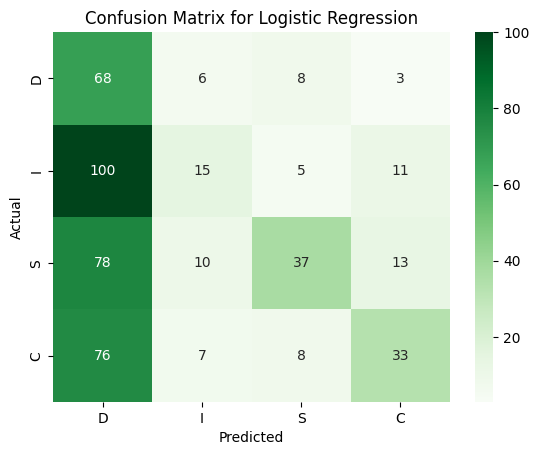

In [67]:
conf_matrix_log_reg = confusion_matrix(Y_test.argmax(axis=1), y_pred_log_reg.argmax(axis=1))
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Greens',
            xticklabels=['D', 'I', 'S', 'C'], yticklabels=['D', 'I', 'S', 'C'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

## Train an MLP

In [57]:
mlp = Sequential()
mlp.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
mlp.add(Dropout(0.1))
mlp.add(Dense(336, activation='relu'))
mlp.add(Dropout(0.1))
mlp.add(Dense(4, activation='sigmoid'))


In [58]:
mlp.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [59]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = mlp.fit(X_train, Y_train, epochs=30, batch_size=32, callbacks=early_stop, validation_split=0.2, verbose=1)

Epoch 1/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2729 - loss: 0.5905 - val_accuracy: 0.3220 - val_loss: 0.5531
Epoch 2/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3049 - loss: 0.5570 - val_accuracy: 0.3089 - val_loss: 0.5545
Epoch 3/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2919 - loss: 0.5574 - val_accuracy: 0.2801 - val_loss: 0.5539
Epoch 4/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2957 - loss: 0.5567 - val_accuracy: 0.2932 - val_loss: 0.5575
Epoch 5/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3166 - loss: 0.5552 - val_accuracy: 0.3168 - val_loss: 0.5513
Epoch 6/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3246 - loss: 0.5501 - val_accuracy: 0.3351 - val_loss: 0.5482
Epoch 7/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3461 - loss: 0.5472 - val_accuracy: 0.3325 - val_loss: 0.5451
Epoch 8/30
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3435 - loss: 0.5379 - val_accuracy: 0.2958 - val_loss:

In [60]:
loss, accuracy = mlp.evaluate(X_test, Y_test)
print('Test Loss: ', loss)
print('Test Accuracy: ', accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3899 - loss: 0.5390 
Test Loss:  0.5421134233474731
Test Accuracy:  0.3933054506778717


In [ ]:
threshold = 0.4
y_pred_probs_mlp = mlp.predict(X_test)
# y_pred_mlp = np.where(y_pred_probs_mlp >= threshold, 1, 0)
y_pred_mlp = (y_pred_probs_mlp >= threshold).astype(int)
# confusion_matrix_mlp = confusion_matrix(Y_test.argmax(axis=1, y_pred_mlp.argmax(axis=1))


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
y_pred_probs_mlp:  [[0.16618352 0.21605238 0.3977572  0.2726747 ]
 [0.37143984 0.33773398 0.23940296 0.17208354]
 [0.3201394  0.39322805 0.22665733 0.11904769]
 ...
 [0.2384331  0.32046223 0.26515827 0.22384773]
 [0.24568248 0.17818789 0.31917986 0.39933974]
 [0.4037457  0.31393045 0.19681773 0.12904312]]


In [63]:
print(Y_train.sum(axis=0))  # Count of D, I, S, C in training data

[418 451 536 505]


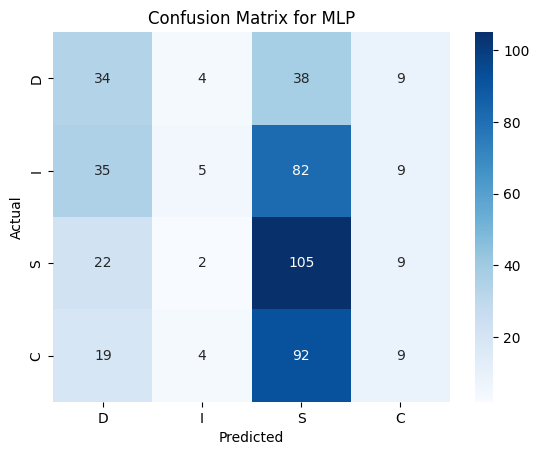

In [68]:
conf_matrix_mlp = confusion_matrix(Y_test.argmax(axis=1), y_pred_mlp.argmax(axis=1))
sns.heatmap(conf_matrix_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['D', 'I', 'S', 'C'], yticklabels=['D', 'I', 'S', 'C'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for MLP')
plt.show()

## Plot Training History